In [1]:
import numpy as np
import xarray as xr
from pathlib import Path
from dask.distributed import Client
import matplotlib.pyplot as plt

In [2]:
# Load wind and solar CF data
wind = xr.open_dataset("data/processed/daily-state-cf/wind_daily-state-cf.nc")
solar = xr.open_dataset("data/processed/daily-state-cf/solar_daily-state-cf.nc")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [3]:
def mean_below_threshold(data, threshold, length_max, length_min):
    '''
    Calculate "mean below threshold" events, as defined in:
        - https://www.nature.com/articles/s41467-026-72681-5
        - https://iopscience.iop.org/article/10.1088/1748-9326/ab91e9

    Where an event is a period where the mean is below the given threshold, and longer events are captured first and then removed from the analysis

    INPUTS
    data: xarray dataarray containing a time series of data (with dimension "time")
    threshold: threshold below which to define events
    length_max: maximum length of drought to look for, should be set as large as possible (no larger than the time dimension) to capture longest droughts
    length_min: minimum length of an event

    OUTPUT
    data array indicating when events occurred (including every time step within the event) and a "length" dimension to indicate the length of the event
    '''
    
    windows = list(range(length_max, length_min-1, -1))  # largest → smallest
    lull_list = []
    counted_lulls = xr.zeros_like(data, dtype=bool)
    
    for w in windows:
    
        rolling_mean = data.rolling(time=w, center=False).mean()
        w_lulls = xr.where(rolling_mean < threshold, 1, 0)
        # count every point inside the window as part of the lull
        reverse_roll = w_lulls.shift(time=-(w - 1))
        w_lulls = (
            reverse_roll
            .rolling(time=w, center=False)
            .max()
            .fillna(0)
            .astype(bool)
        )
        # only count droughts not counted in a longer period
        new_lulls = w_lulls & (~counted_lulls)
        lull_list.append(new_lulls.expand_dims(length=[w]))
        # ensure droughts lasting longer than the given window are not counted multiple times

        counted_lulls = counted_lulls | new_lulls

    return xr.concat(lull_list, dim="length")

In [4]:
data = wind.V.sel(time=slice('2020-05', '2020-07'))

In [5]:
lulls = mean_below_threshold(
    data=data,
    threshold=0.05,
    length_max=30,
    length_min=3
)

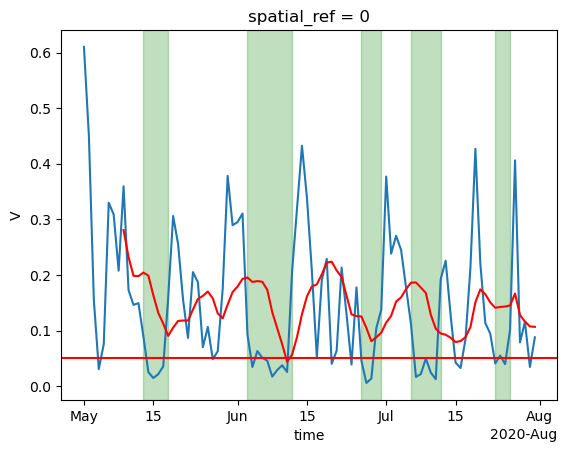

In [6]:
lull_mask = lulls.any("length")
# lull_mask = lull_mask.fillna(False)

fig, ax = plt.subplots()

data.plot(ax=ax, label="capacity factor")

t = lull_mask.time.values
m = lull_mask.values

in_lull = False
start = None

for ti, mi in zip(t, m):

    if mi and not in_lull:
        start = ti
        in_lull = True

    elif not mi and in_lull:
        ax.axvspan(start, ti, color="green", alpha=0.25)
        in_lull = False

# close last span
if in_lull:
    ax.axvspan(start, t[-1], color="green", alpha=0.25)

data.rolling(time=9).mean().plot(ax=ax, c='r')
ax.axhline(0.05, c='r')

In [7]:
longest_lull = lulls.any("time").where(lambda x: x, drop=True).length.max()

In [8]:
longest_lull.item()

9